# M87 Black Hole Image Reconstruction 🌌

## 1. Imports and Setup 🛠️

In [15]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
import finufft
import jax
from scipy.optimize import minimize

%matplotlib inline

print("All dependencies imported successfully!")

All dependencies imported successfully!


## 2. Data Loading & Initial Exploration 🗂️

In [16]:
UVFITS_PATH = Path(
    "data/EHTC_FirstM87Results_Apr2019/uvfits/"
    "SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits"
)

if not UVFITS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {UVFITS_PATH}. Please check your dataset path."
    )

with fits.open(UVFITS_PATH, memmap=False) as hdul:
    print("FITS Structure:")
    hdul.info()
    
    header = hdul[0].header
    data = hdul[0].data

print("\nKey Header Information:")
for key in ["OBJECT", "TELESCOP", "DATE-OBS", "CRVAL4"]:
    if key in header:
        print(f"  {key} = {header[key]}")

FITS Structure:
Filename: data\EHTC_FirstM87Results_Apr2019\uvfits\SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 GroupsHDU       82   (3, 4, 1, 1, 1, 1)   float32   6458 Groups  9 Parameters
  1  AIPS AN       1 BinTableHDU     60   8R x 13C   [8A, 3D, 1E, 1J, 1J, 1E, 1A, 1E, 3E, 1A, 1E, 3E, 1D]   
  2  AIPS FQ       1 BinTableHDU     21   1R x 5C   [1J, 1D, 1E, 1E, 1J]   

Key Header Information:
  OBJECT = M87
  TELESCOP = VLBA
  DATE-OBS = 2017-04-05
  CRVAL4 = 229070703125.0


Now we have the basic strucure of the data figured out we can turn it into a pandas DataFrame which will make it much easier to work with. The original UVFITS format contains the measurements in a multidimensional array, which can be difficult to work with directly. A DataFrame gives us a much simpler table containing the quantities we will use during the reconstruction:

* `u` — Fourier-plane u coordinate
* `v` — Fourier-plane v coordinate
* `real` — real component of the complex visibility
* `imag` — imaginary component of the complex visibility
* `weight` — measurement weight

This should give us one row per measurement, with 6,458 measurements in total.

In [17]:
parnames = list(data.parnames)
u_name = next((p for p in parnames if p.upper() in ["UU---SIN", "UU"]), None)
v_name = next((p for p in parnames if p.upper() in ["VV---SIN", "VV"]), None)

u_sec = np.asarray(data.par(u_name), dtype=np.float64)
v_sec = np.asarray(data.par(v_name), dtype=np.float64)

raw = np.asarray(data.data)
comp_axis = [i for i, n in enumerate(raw.shape[1:]) if n == 3][-1]
arr = np.moveaxis(raw, comp_axis + 1, -1)
arr = arr.reshape(arr.shape[0], -1, 3)

stokes_I = arr[:, 0, :]
real = np.asarray(stokes_I[:, 0], dtype=np.float64)
imag = np.asarray(stokes_I[:, 1], dtype=np.float64)
weight = np.asarray(stokes_I[:, 2], dtype=np.float64)

frequency = float(header.get("CRVAL4", 299792458.0 / 1.3e-3))
u_Glambda = (u_sec * frequency) / 1e9
v_Glambda = (v_sec * frequency) / 1e9

# Build Pandas DataFrame 
df = pd.DataFrame({
    "u_Glambda": u_Glambda,
    "v_Glambda": v_Glambda,
    "real": real,
    "imag": imag,
    "weight": weight,
    "amplitude": np.hypot(real, imag),
    "phase": np.arctan2(imag, real),
    "baseline_Glambda": np.hypot(u_Glambda, v_Glambda)
})

df.head()

,u_Glambda,v_Glambda,real,imag,weight,amplitude,phase,baseline_Glambda
0,1.081710,-3.833722,-0.006917,-0.012507,14626.224609,0.014292,-2.075989,3.983406
1,-4.399933,-4.509480,0.136019,0.013969,20262.142578,0.136734,0.102343,6.300383
2,0.000835,-0.001722,0.591577,0.950759,18189.121094,1.119780,1.014202,0.001914
3,1.080840,-3.832004,-0.013640,-0.012420,251.636246,0.018448,-2.402974,3.981516
4,-4.400757,-4.507747,0.075689,-0.117322,470.743378,0.139619,-0.997846,6.299718


## 3. Exploratory Data Visualization 📈

### Fourier $(u, v)$ Plane Coverage

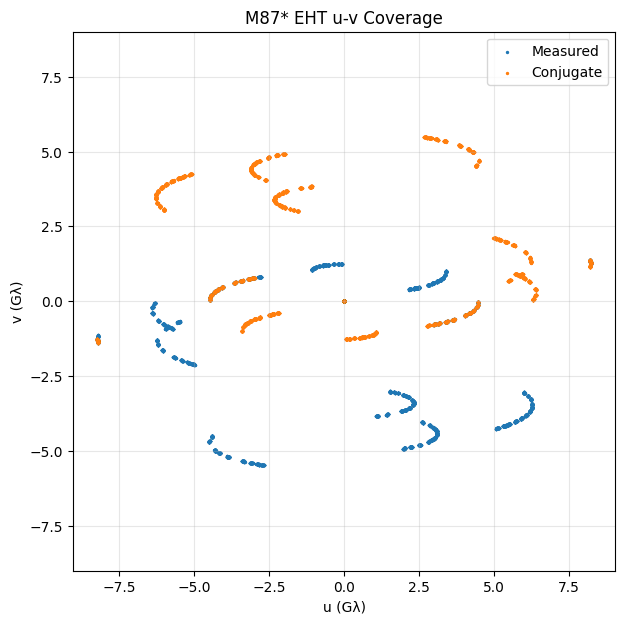

In [18]:
plt.figure(figsize=(7, 7))
plt.scatter(df["u_Glambda"], df["v_Glambda"], s=2, label="Measured")
plt.scatter(-df["u_Glambda"], -df["v_Glambda"], s=2, label="Conjugate")
plt.xlabel("u (Gλ)")
plt.ylabel("v (Gλ)")
plt.title("M87* EHT u-v Coverage")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Visibility Amplitudes Binned across Baseline Lengths



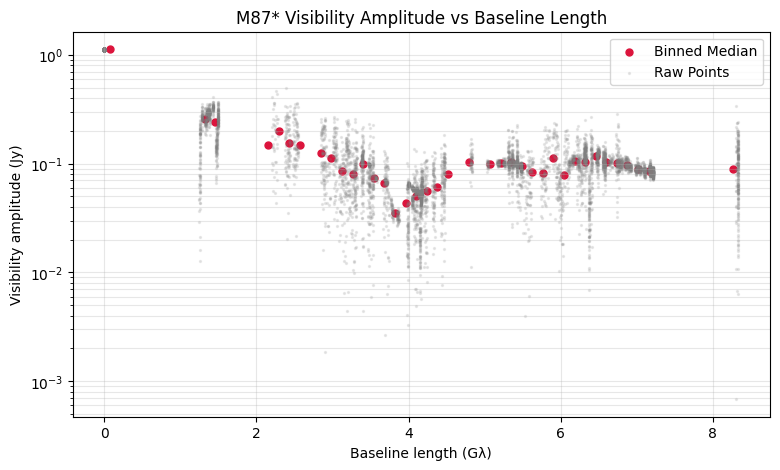

In [19]:
n_bins = 60
bin_edges = np.linspace(df["baseline_Glambda"].min(), df["baseline_Glambda"].max(), n_bins + 1)
df["baseline_bin"] = pd.cut(df["baseline_Glambda"], bins=bin_edges)

grouped = df.groupby("baseline_bin", observed=True)
binned_amplitude = grouped["amplitude"].median()
bin_centers = np.array([interval.mid for interval in binned_amplitude.index])

plt.figure(figsize=(9, 5))
plt.scatter(bin_centers, binned_amplitude, color="crimson", s=25, label="Binned Median")
plt.scatter(df["baseline_Glambda"], df["amplitude"], s=2, alpha=0.15, color="gray", label="Raw Points")
plt.xlabel("Baseline length (Gλ)")
plt.ylabel("Visibility amplitude (Jy)")
plt.yscale("log")
plt.title("M87* Visibility Amplitude vs Baseline Length")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## 4. Creating a Dirty Image 🖼️

he dirty image is obtained by directly applying the inverse Fourier transform to the measured visibility data. The visibility coordinates $(u,v)$ are converted from seconds to wavelengths using the observing frequency, and Hermitian conjugates are added to enforce a real-valued image.

The dirty image is given by

$$
I_{\mathrm{dirty}}(x,y)
=
\frac{1}{\sum_i w_i}
\sum_i
w_i V_i
e^{2\pi i(u_i x+v_i y)},
$$

where $V_i$ are the measured complex visibilities, $(u_i,v_i)$ are the corresponding baseline coordinates in wavelengths, and $w_i$ are the visibility weights.

The corresponding dirty beam is calculated from the sampling function alone,

$$
B(x,y)
=
\frac{1}{\sum_i w_i}
\sum_i
w_i e^{2\pi i(u_i x+v_i y)}.
$$

Both the dirty image and dirty beam are subsequently normalised to their maximum absolute value for visualisation.

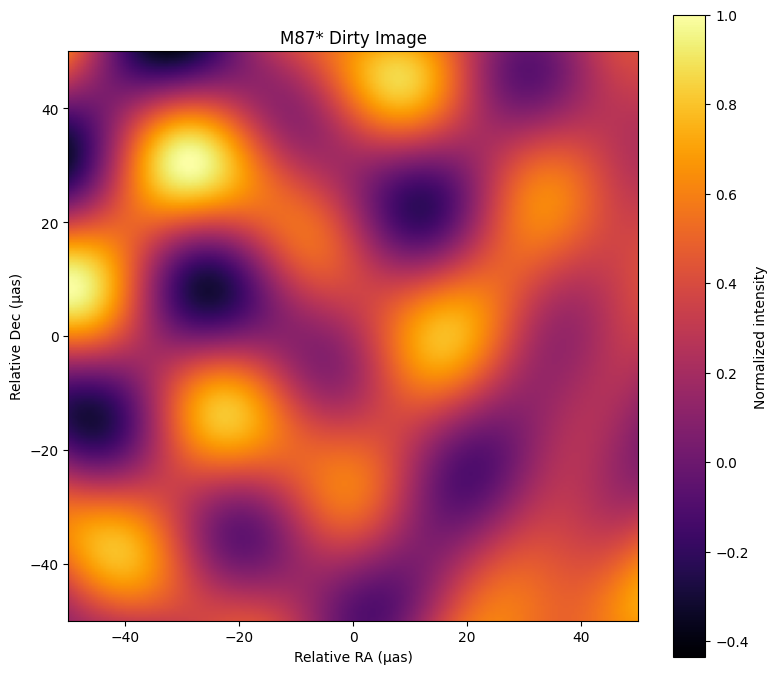

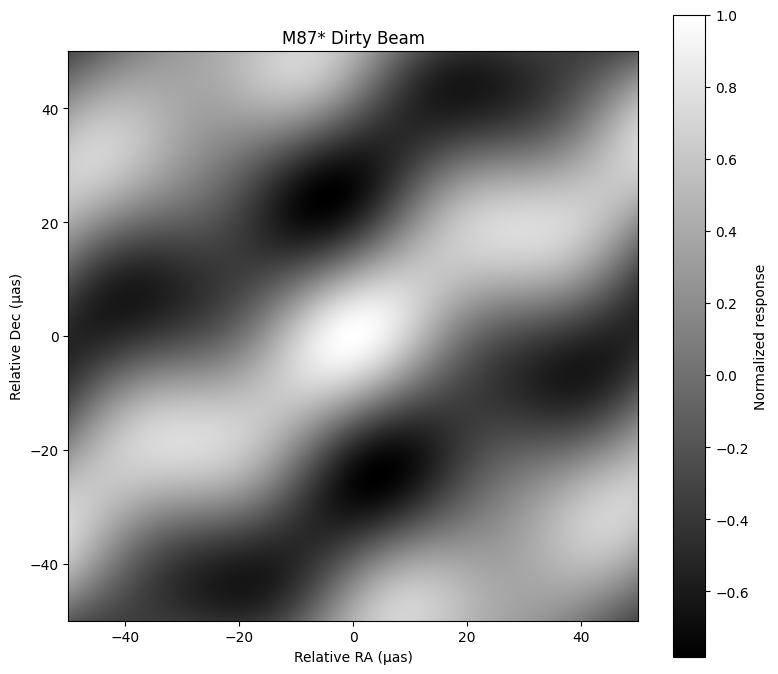

In [ ]:
# %% [markdown]
# ## 4. Simple Dirty Image Reconstruction

# %%

# Image size
N = 256
FOV_UAS = 128.0

# Convert microarcseconds to radians
uas_to_rad = np.pi / (180 * 3600 * 1e6)

# Image pixel size
pixel_rad = FOV_UAS * uas_to_rad / N

# Image coordinates
axis = (np.arange(N) - (N - 1) / 2) * pixel_rad
X, Y = np.meshgrid(axis, axis)

# Prepare visibility data
visibility = real + 1j * imag

good = (
    np.isfinite(u_sec) &
    np.isfinite(v_sec) &
    np.isfinite(visibility.real) &
    np.isfinite(visibility.imag) &
    np.isfinite(weight) &
    (weight > 0)
)

u0 = u_sec[good]
v0 = v_sec[good]
V0 = visibility[good]
W0 = weight[good]

# Convert seconds -> wavelengths
frequency = header["CRVAL4"]

u0 *= frequency
v0 *= frequency

# Add Hermitian conjugates
u_all = np.r_[u0, -u0]
v_all = np.r_[v0, -v0]
V_all = np.r_[V0, np.conj(V0)]
W_all = np.r_[W0, W0]

# Direct inverse Fourier transform
dirty = np.zeros((N, N), dtype=np.complex128)
beam = np.zeros((N, N), dtype=np.complex128)

for ui, vi, Vi, wi in zip(u_all, v_all, V_all, W_all):

    phase = np.exp(
        2j * np.pi * (ui * X + vi * Y)
    )

    dirty += wi * Vi * phase
    beam += wi * phase

# Normalize
dirty = dirty.real / W_all.sum()
beam = beam.real / W_all.sum()

dirty /= np.max(np.abs(dirty))
beam /= np.max(np.abs(beam))

# Plot
extent = [
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad,
    axis[0] / uas_to_rad,
    axis[-1] / uas_to_rad
]

plt.figure(figsize=(8, 7))

plt.imshow(
    dirty,
    origin="lower",
    extent=extent,
    cmap="inferno"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Image")

plt.colorbar(label="Normalized intensity")
plt.tight_layout()
plt.show()

# Dirty beam
plt.figure(figsize=(8, 7))

plt.imshow(
    beam,
    origin="lower",
    extent=extent,
    cmap="gray"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Dirty Beam")

plt.colorbar(label="Normalized response")
plt.tight_layout()
plt.show()

## 5. Image Reconstruction 📸

In [ ]:
#Paramters
NPIX = 496
FOV_UAS = 128.0
MAXITER = 500
MAX_VIS = None
CHUNK = 256
ENTROPY_WEIGHT = 0.004
SMOOTHNESS_WEIGHT = 0.02
EPS = 1e-12


#Set up Image Grid
fov_rad = FOV_UAS * uas_to_rad
pixel_rad = fov_rad / NPIX
pixel_area = pixel_rad**2

axis_rad = (np.arange(NPIX) - (NPIX - 1) / 2) * pixel_rad
X, Y = np.meshgrid(axis_rad, axis_rad)
Xf, Yf = X.ravel(), Y.ravel()
n_pix = NPIX**2


#Prepare visibilities
V = real + 1j * imag

good = (
    np.isfinite(u_sec) & np.isfinite(v_sec) &
    np.isfinite(V.real) & np.isfinite(V.imag) &
    np.isfinite(weight) & (weight > 0)
)

u = -u_sec[good] * frequency
v = -v_sec[good] * frequency
V = V[good]
W = weight[good]

if MAX_VIS and len(V) > MAX_VIS:
    rng = np.random.default_rng(12345)
    take = rng.choice(len(V), MAX_VIS, replace=False)
    u, v, V, W = u[take], v[take], V[take], W[take]

u = np.r_[u, -u]
v = np.r_[v, -v]
V = np.r_[V, np.conj(V)]
W = np.r_[W, W]

W /= np.median(W)
weight_sum = W.sum()

baseline = np.hypot(u, v)
short = baseline <= np.percentile(baseline, 5)
flux0 = np.mean(np.abs(V[short]))
flux0 = flux0 if np.isfinite(flux0) and flux0 > 0 else 1.0

print("Visibilities used:", len(V))
print("Initial flux:", flux0, "Jy")


Visibilities used: 12916
Initial flux: 1.1244142084014175 Jy


### Initial Guess

A 2D Gaussian is used as the initial estimate for the image, with a standard deviation of $\sigma = 15$ uas converted to radians. The Gaussian is normalised such that its total integrated flux is unity, and is then scaled by the initial flux $F_0$.

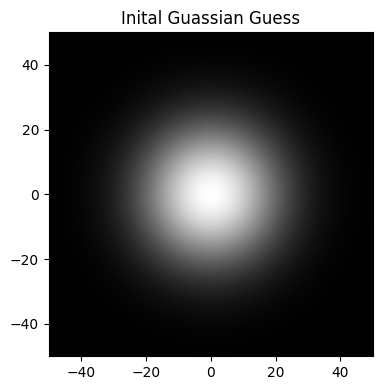

In [22]:
##Inital guess
sigma = 15 * uas_to_rad
g = np.exp(-(X**2 + Y**2)/(2*sigma**2))
g /= g.sum() * pixel_area

image0 = flux0 * g
plt.figure(figsize=(4,4))

plt.imshow(
    image0,
    origin="lower",
    extent=extent,
    cmap="gray"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.title("Inital Guassian Guess")

plt.tight_layout()
plt.show()

### FINUFFT Fourier Operators

The forward operator computes the Fourier transform of the image at the non-uniform $(u,v)$ coordinates using FINUFFT. The image is flattened and multiplied by the pixel area to approximate the continuous Fourier integral,

$$
V(u,v) =
\int I(x,y)e^{-2\pi i(ux+vy)}\,dx\,dy
\approx
\sum_{j} I_j e^{-2\pi i(ux_j+vy_j)}\,\Delta A.
$$

The adjoint operator maps the Fourier-domain residuals back into the image plane using the corresponding adjoint transform.

In [23]:
# FINUFFT Fourier operators 

# Image-plane flattened
x_img = Xf.astype(np.float64)
y_img = Yf.astype(np.float64)

s_uv = 2 * np.pi * u
t_uv = 2 * np.pi * v

def forward(image):
    image = np.asarray(image).ravel().astype(np.complex128)

    return finufft.nufft2d3(
        x_img,
        y_img,
        image * pixel_area,
        s_uv,
        t_uv,
        isign=-1,
        eps=1e-11,
    )


def adjoint(residual):
    residual = np.asarray(residual).ravel().astype(np.complex128)

    return finufft.nufft2d3(
        s_uv,
        t_uv,
        residual,
        x_img,
        y_img,
        isign=+1,
        eps=1e-11,
    ) * pixel_area

### Optimisation

In [24]:
# Positive image parameterisation
def unpack(z):
    q = z[:-1]
    q = q - q.max()

    p = np.exp(np.clip(q, -50, 50))
    p /= p.sum()

    flux = np.exp(np.clip(z[-1], -10, 10))
    image = flux * p / pixel_area

    return image, flux


q0 = np.log(np.maximum(image0.ravel() * pixel_area, EPS))
z0 = np.r_[q0, np.log(flux0)]

# Objective
counter = 0
def objective(z):

    global counter
    counter += 1

    image, flux = unpack(z)

    predicted = forward(image)
    residual = predicted - V

    chi2 = np.sum(W * (residual.real**2 + residual.imag**2)) / weight_sum

    # Simple entropy regularisation
    p = image * pixel_area
    p /= p.sum() + EPS
    entropy = np.sum(
        np.clip(p, EPS, None) *
        np.log(np.clip(p, EPS, None))
    )

    # Smoothness
    img = image.reshape(NPIX, NPIX)
    scale = img.mean() + EPS

    smooth = (
        np.mean(np.diff(img, axis=1)**2) +
        np.mean(np.diff(img, axis=0)**2)
    ) / scale**2

    value = (
        chi2 +
        ENTROPY_WEIGHT * entropy +
        SMOOTHNESS_WEIGHT * smooth
    )

    # Gradient

    grad_image = (
        2 * np.real(
            adjoint(W * residual)
        ) / weight_sum
    )

    q = z[:-1]
    q = q - q.max()

    p = np.exp(np.clip(q, -50, 50))
    p /= p.sum()

    grad_pixel = grad_image * flux / pixel_area
    mean_grad = np.sum(p * grad_pixel)

    grad_q = p * (grad_pixel - mean_grad)

    grad_flux = np.sum(
        grad_image * image.ravel()
    )

    gradient = np.r_[
        grad_q,
        grad_flux
    ]

    if counter % 5 == 0:
        print(
            f"Iteration {counter:3d} | "
            f"error = {chi2:.6g}"
        )

    return float(value), gradient

In [25]:
# Optimise
print("Starting reconstruction...")

result = minimize(
    objective,
    z0,
    method="L-BFGS-B",
    jac=True,
    options={
        "maxiter": MAXITER,
        "ftol": 1e-9,
        "gtol": 1e-6
    }
)

# Final image
image, recovered_flux = unpack(result.x)
image = image.reshape(NPIX, NPIX)

model_vis = forward(image)
residual = model_vis - V

chi2 = np.sum(
    W * (residual.real**2 + residual.imag**2)
) / weight_sum

print("\nFinished.")
print("Success:", result.success)
print("Iterations:", result.nit)
print("Recovered flux:", recovered_flux, "Jy")
print("Final chi-square:", chi2)


Starting reconstruction...
Iteration   5 | error = 0.0790472
Iteration  10 | error = 0.0788359
Iteration  15 | error = 0.0787596
Iteration  20 | error = 0.0776005
Iteration  25 | error = 0.0774869
Iteration  30 | error = 0.0774879
Iteration  35 | error = 0.0774879
Iteration  40 | error = 0.0774879
Iteration  45 | error = 0.0774877
Iteration  50 | error = 0.0774846
Iteration  55 | error = 0.0773968
Iteration  60 | error = 0.0773
Iteration  65 | error = 0.0773053
Iteration  70 | error = 0.0772722
Iteration  75 | error = 0.0772015
Iteration  80 | error = 0.0772056
Iteration  85 | error = 0.0772032
Iteration  90 | error = 0.0772025
Iteration  95 | error = 0.0772026
Iteration 100 | error = 0.0772026
Iteration 105 | error = 0.0772026
Iteration 110 | error = 0.0772003
Iteration 115 | error = 0.0771947
Iteration 120 | error = 0.0770669
Iteration 125 | error = 0.0770605

Finished.
Success: True
Iterations: 55
Recovered flux: 0.246062764660312 Jy
Final chi-square: 0.07706054010786909


### Final Render

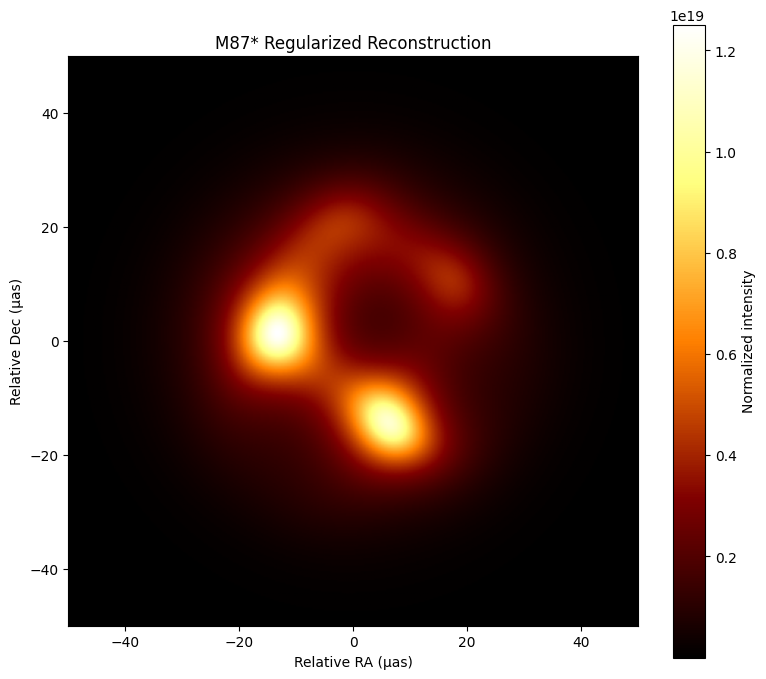

In [26]:
extent = [
    axis_rad[0] / uas_to_rad,
    axis_rad[-1] / uas_to_rad,
    axis_rad[0] / uas_to_rad,
    axis_rad[-1] / uas_to_rad
]

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    image,
    origin="lower",
    extent=extent,
    cmap="afmhot"
)

plt.xlim(-50, 50)
plt.ylim(-50, 50)

plt.xlabel("Relative RA (μas)")
plt.ylabel("Relative Dec (μas)")
plt.title("M87* Regularized Reconstruction")

plt.colorbar(
    label="Normalized intensity"
)

plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ------------------------------------------------------------
# Regularisation sweep
# ------------------------------------------------------------

ENTROPY_VALUES = [
    0.0005,
    0.001,
    0.002,
    0.004,
    0.008
]

SMOOTHNESS_VALUES = [
    0.0025,
    0.005,
    0.01,
    0.02,
    0.04
]

sweep_images = {}
sweep_chi2 = {}
sweep_flux = {}

print("Starting regularisation sweep...")
print(
    f"{len(ENTROPY_VALUES) * len(SMOOTHNESS_VALUES)} "
    "reconstructions"
)

for entropy_weight in ENTROPY_VALUES:

    for smoothness_weight in SMOOTHNESS_VALUES:

        print(
            f"\nEntropy = {entropy_weight:g}, "
            f"Smoothness = {smoothness_weight:g}"
        )

        # Change global weights used by objective()
        ENTROPY_WEIGHT = entropy_weight
        SMOOTHNESS_WEIGHT = smoothness_weight

        # Reset counter
        counter = 0

        result = minimize(
            objective,
            z0,
            method="L-BFGS-B",
            jac=True,
            options={
                "maxiter": MAXITER,
                "ftol": 1e-9,
                "gtol": 1e-6
            }
        )

        # Reconstruct image
        image, recovered_flux = unpack(result.x)
        image = image.reshape(NPIX, NPIX)

        # Calculate final chi-square separately
        model_vis = forward(image)
        residual = model_vis - V

        chi2 = np.sum(
            W * (
                residual.real**2 +
                residual.imag**2
            )
        ) / weight_sum

        key = (
            entropy_weight,
            smoothness_weight
        )

        sweep_images[key] = image.copy()
        sweep_chi2[key] = chi2
        sweep_flux[key] = recovered_flux

        print(
            f"  chi2 = {chi2:.6g}, "
            f"flux = {recovered_flux:.4g}, "
            f"success = {result.success}"
        )

Starting regularisation sweep...
25 reconstructions

Entropy = 0.0005, Smoothness = 0.0025
Iteration   5 | error = 0.0790472
Iteration  10 | error = 0.0788359
Iteration  15 | error = 0.0787596
Iteration  20 | error = 0.0776005
Iteration  25 | error = 0.0774826
Iteration  30 | error = 0.0774474
Iteration  35 | error = 0.0771196
Iteration  40 | error = 0.0770763
Iteration  45 | error = 0.0768777
  chi2 = 0.0768733, flux = 0.2303, success = True

Entropy = 0.0005, Smoothness = 0.005
Iteration   5 | error = 0.0790472
Iteration  10 | error = 0.0788359
Iteration  15 | error = 0.0787596
Iteration  20 | error = 0.0776005
Iteration  25 | error = 0.0774826
Iteration  30 | error = 0.0774441
Iteration  35 | error = 0.0771918
  chi2 = 0.0771192, flux = 0.2446, success = True

Entropy = 0.0005, Smoothness = 0.01
Iteration   5 | error = 0.0790472
Iteration  10 | error = 0.0788359
Iteration  15 | error = 0.0787596
Iteration  20 | error = 0.0776005
Iteration  25 | error = 0.0774827
Iteration  30 | erro

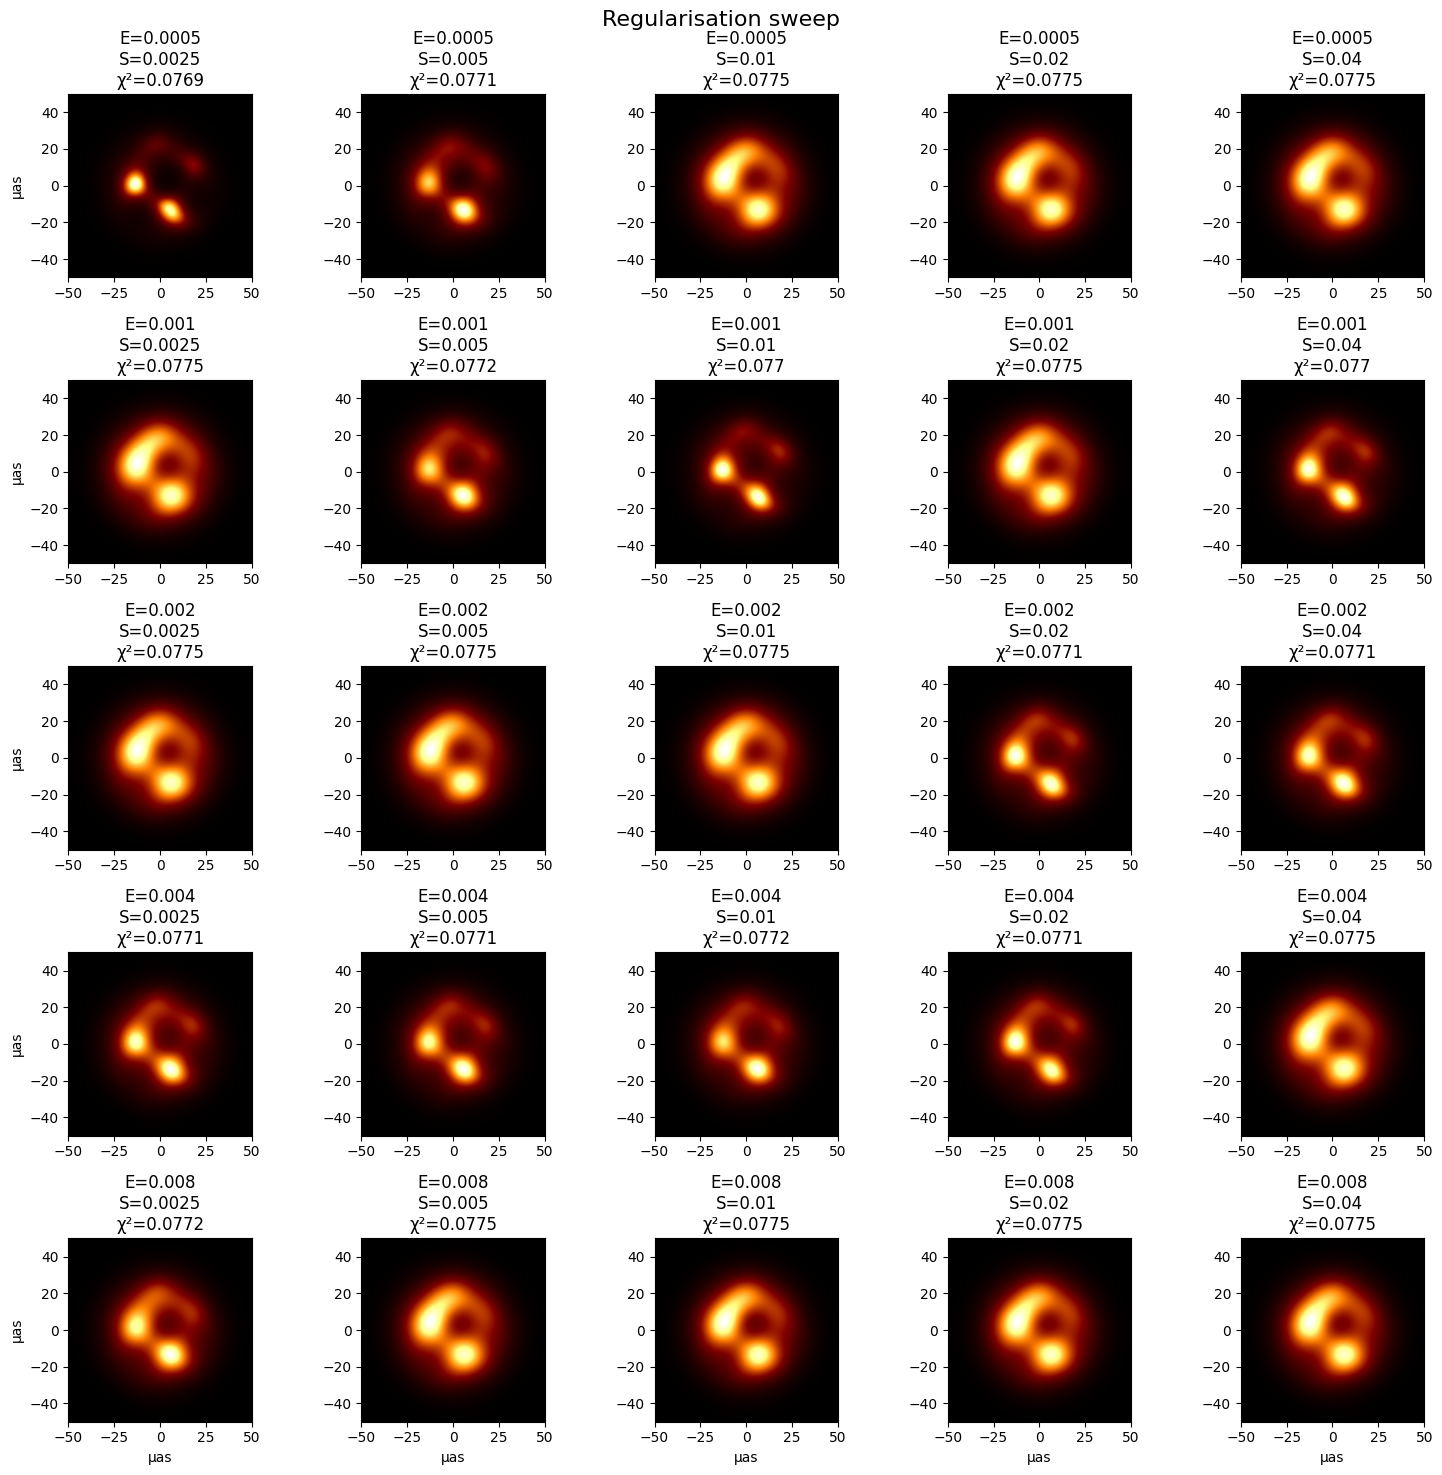

In [28]:
# ------------------------------------------------------------
# Plot reconstruction sweep
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(ENTROPY_VALUES),
    len(SMOOTHNESS_VALUES),
    figsize=(15, 15)
)

for i, entropy_weight in enumerate(ENTROPY_VALUES):

    for j, smoothness_weight in enumerate(SMOOTHNESS_VALUES):

        key = (
            entropy_weight,
            smoothness_weight
        )

        image = sweep_images[key]
        chi2 = sweep_chi2[key]

        ax = axes[i, j]

        im = ax.imshow(
            image,
            origin="lower",
            extent=extent,
            cmap="afmhot"
        )

        ax.set_title(
            f"E={entropy_weight:g}\n"
            f"S={smoothness_weight:g}\n"
            f"χ²={chi2:.3g}"
        )

        ax.set_xlim(-50, 50)
        ax.set_ylim(-50, 50)

        if i == len(ENTROPY_VALUES) - 1:
            ax.set_xlabel("μas")

        if j == 0:
            ax.set_ylabel("μas")

plt.suptitle(
    "Regularisation sweep",
    fontsize=16
)

plt.tight_layout()
plt.show()